# ML2_Supervised learning


## 1. Answer the questions

### **1.1 Analytical Solution to Linear Regression**

### **Problem in vector form**
Feature matrix: $X \in \mathbb{R}^{n \times d}$  
Target vector: $y \in \mathbb{R}^n$  
Weight vector: $w \in \mathbb{R}^d$

**Model**: $\hat{y} = Xw$

### **Minimizing MSE**
Loss function:

$$ L(w) = \frac{1}{n} \|y - Xw\|^2 = \frac{1}{n}(y - Xw)^\top (y - Xw) $$

**Gradient and optimality condition**:

$$ \nabla L(w) = \frac{2}{n}(X^\top X w - X^\top y) = 0 $$
$$ X^\top X w = X^\top y $$

**Analytical solution (normal equation)**:

$$ \hat{w} = (X^\top X)^{-1} X^\top y $$

### **1.2 Changes with Regularization**

### **L2 Regularization (Ridge)**
Adds penalty for large weights:
$$ \mathcal{L}_{\text{ridge}}(w) = \frac{1}{2} \|Xw - y\|^2 + \frac{\lambda}{2} \|w\|_2^2 = \frac{1}{2} (Xw - y)^\top (Xw - y) + \frac{\lambda}{2} \|w\|_2^2 $$

**Solution**:
$$ \hat{w}_{\text{Ridge}} = (X^\top X + \lambda I)^{-1} X^\top y $$

**Changes**:
1. Adds $\lambda I$ to matrix $X^\top X$
2. Matrix is always invertible
3. Weights shrink proportionally to $\lambda$

### **L1 Regularization (Lasso)**
Adds sum of absolute weights:
$$ L_{\text{Lasso}}(w) = \|Xw - y\|^2 + \lambda\|w\|_1 $$
where $\|w\|_1 = \sum_i |w_i|$

**Features**:
1. No closed-form solution
2. Solved by convex optimization (coordinate descent, proximal gradient)
3. Leads to **sparse solutions** (many $w_i = 0$)

### **1.3 Why L1 Selects Features (Weights = 0)**

### **Geometric Explanation**
Minimize $L(w)$ subject to $\|w\|_1 \leq t$:

- **L2 constraint**: sphere → solution usually inside sphere → non-zero weights
- **L1 constraint**: diamond → solution often at a **corner** → some coordinates = 0

### **Mathematical Explanation**
Optimality condition (subgradient):
$$ X_j^\top(y - Xw) = \lambda \cdot \text{sign}(w_j) \quad \text{if } w_j \neq 0 $$
$$ |X_j^\top(y - Xw)| \leq \lambda \quad \text{if } w_j = 0 $$

**Conclusion**: Weight $w_j$ becomes zero when correlation of j-th feature with residuals is less than $\lambda$.

### **1.4 How to Model Nonlinearities with Linear Models**

### **Idea**

The model remains **linear in parameters**, but **nonlinear in features**.

**Approach:**
Replace original features $x$ with nonlinear functions:
$$ \phi(x) = [x, x^2, x^3, \sin x, \log x, \dots] $$

**Model:**
$$ \hat{y} = w^\top \phi(x) $$

**Examples:**
- Polynomial regression
- Interaction features
- Logarithmic transformations
- Feature binning

### **Why It Works**
- Linear in weights $w$
- Nonlinear in original feature space

### **Danger**
- High risk of overfitting
- Almost always requires regularization

## 2. Inroduction

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

import re
from collections import Counter


In [2]:
df_train = pd.read_json('data/train.json')
df_test = pd.read_json('data/test.json')

## 3. Data analysis

### 3.0 drop the rows that are outside the 1 and 99 percentiles from the target column

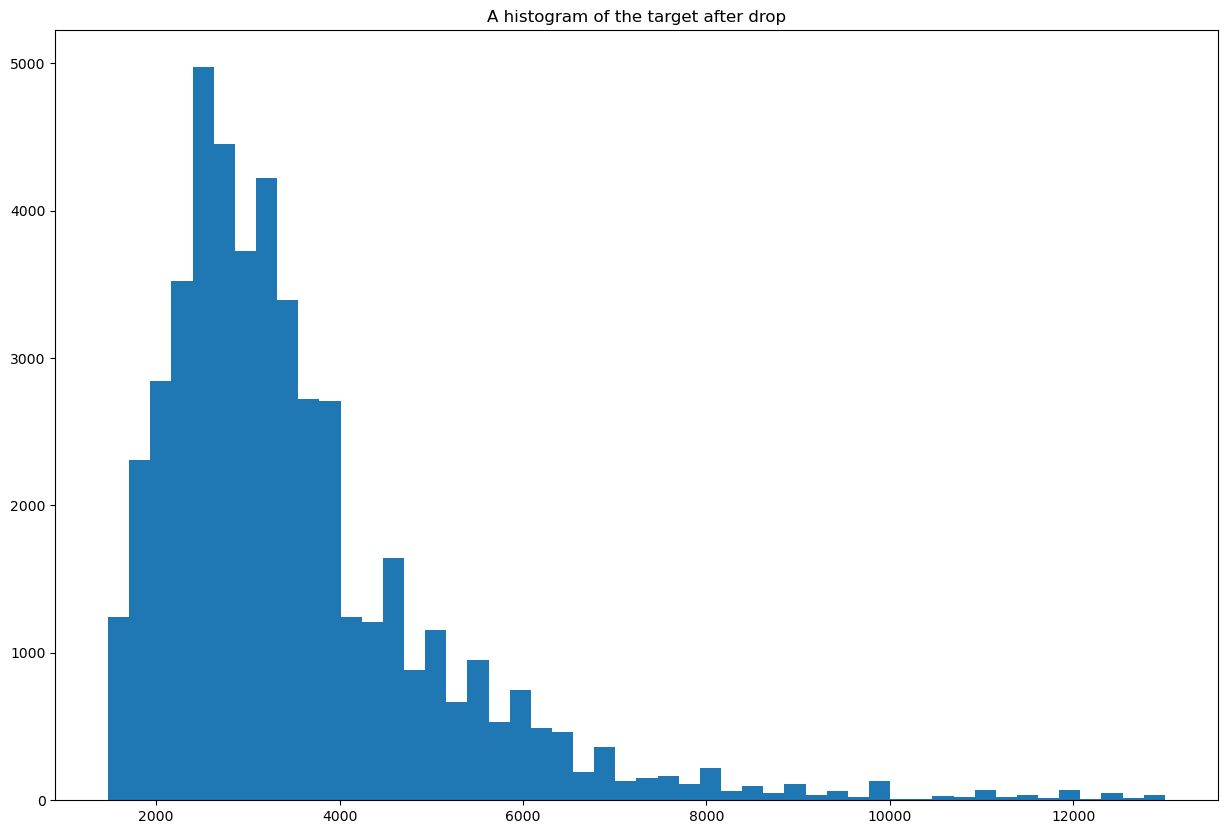

In [3]:
percentile_1 = np.percentile(df_train['price'], 1)
percentile_99 = np.percentile(df_train['price'], 99)
df_train = df_train[(df_train['price'] >= percentile_1) & (df_train['price'] <= percentile_99)].copy()
plt.figure(figsize=(15, 10))
plt.hist(df_train['price'], bins=50)
plt.title('A histogram of the target after drop')
plt.show() 

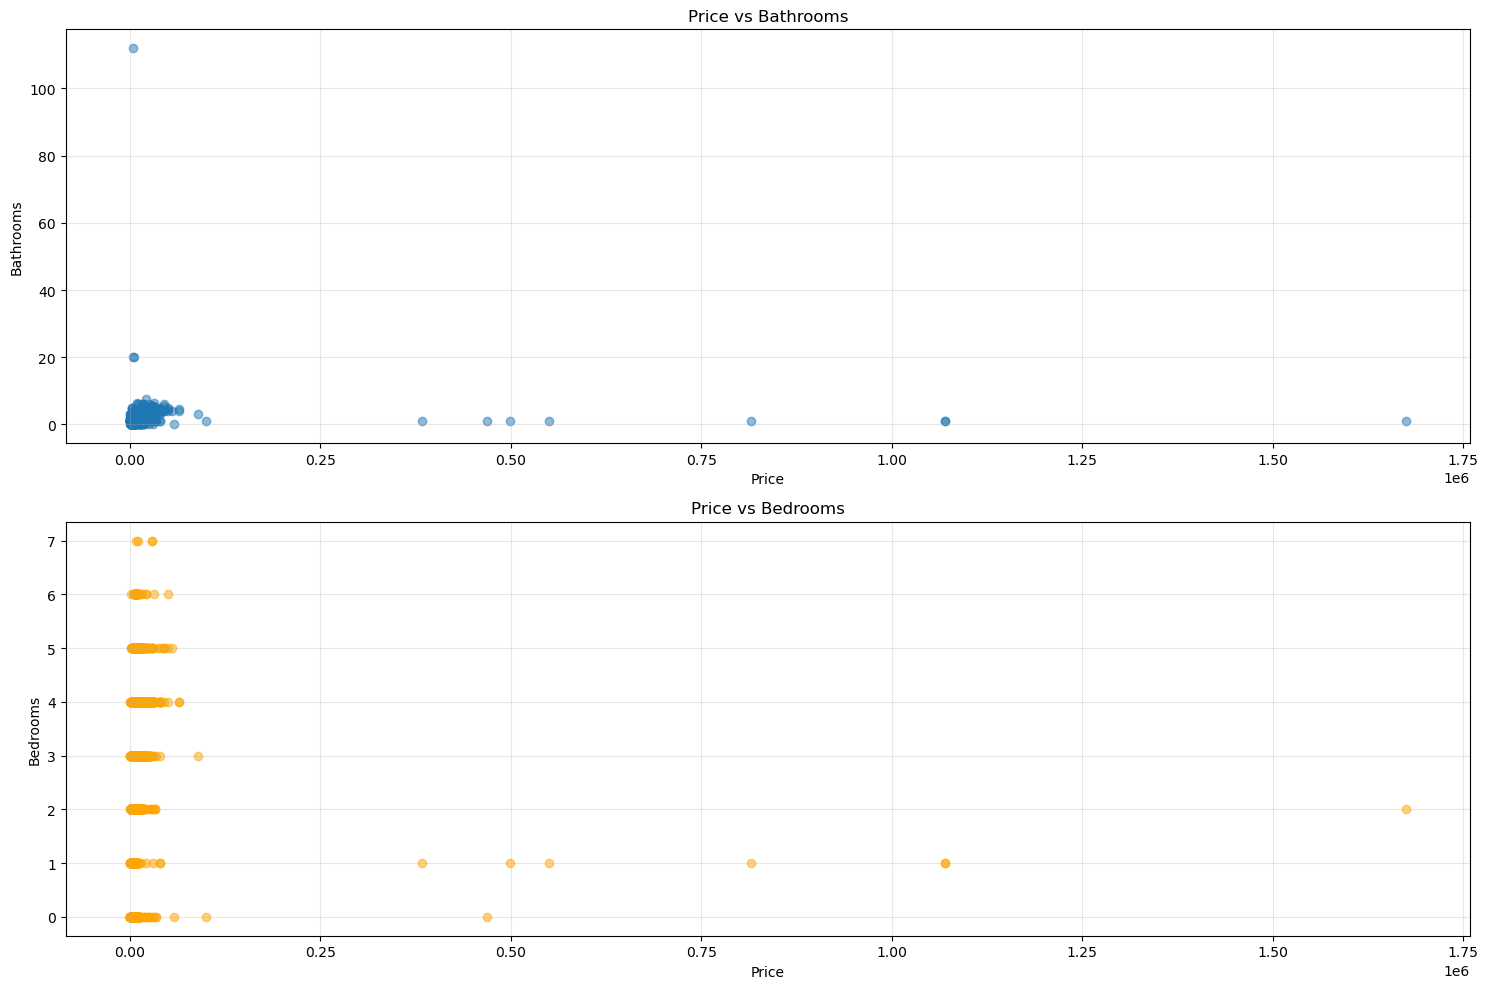

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

ax1.scatter(df_test['price'], df_test['bathrooms'], alpha=0.5)
ax1.set_xlabel('Price')
ax1.set_ylabel('Bathrooms')
ax1.set_title('Price vs Bathrooms')
ax1.grid(True, alpha=0.3)

ax2.scatter(df_test['price'], df_test['bedrooms'], alpha=0.5, color='orange')
ax2.set_xlabel('Price')
ax2.set_ylabel('Bedrooms')
ax2.set_title('Price vs Bedrooms')
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

In [5]:
percentile_1 = np.percentile(df_test['price'], 1)
percentile_99 = np.percentile(df_test['price'], 99)
df_test = df_test[(df_test['price'] >= percentile_1) & (df_test['price'] <= percentile_99)].copy()
df_test = df_test[(df_test['bathrooms'] < 20)].copy()

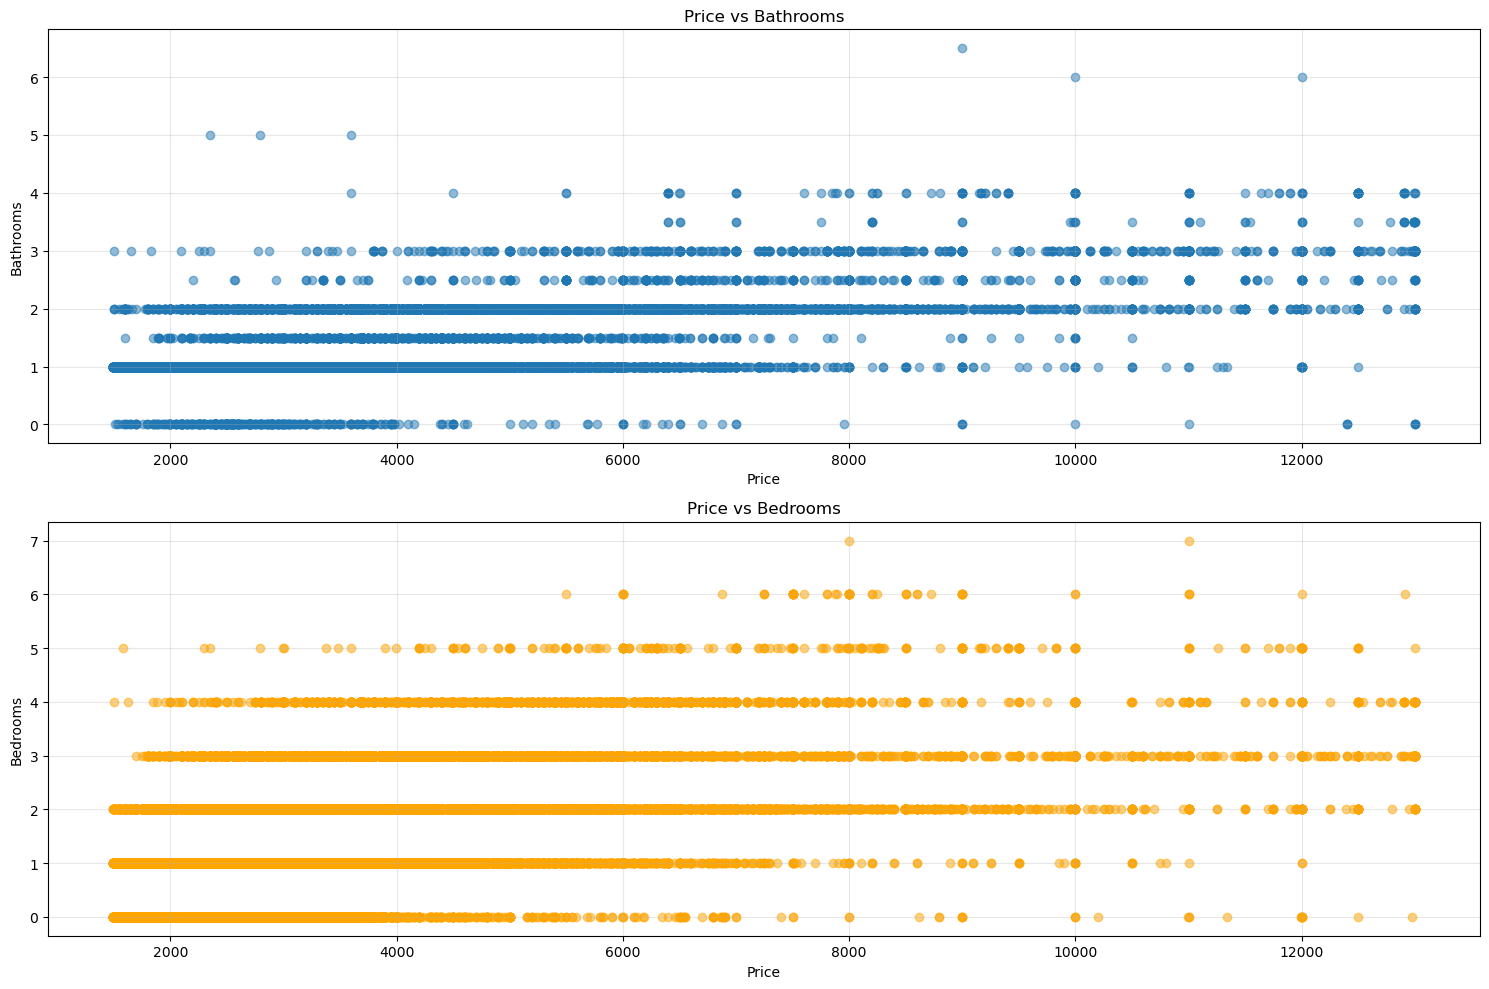

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

ax1.scatter(df_test['price'], df_test['bathrooms'], alpha=0.5)
ax1.set_xlabel('Price')
ax1.set_ylabel('Bathrooms')
ax1.set_title('Price vs Bathrooms')
ax1.grid(True, alpha=0.3)

ax2.scatter(df_test['price'], df_test['bedrooms'], alpha=0.5, color='orange')
ax2.set_xlabel('Price')
ax2.set_ylabel('Bedrooms')
ax2.set_title('Price vs Bedrooms')
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

### 3.1 

In [7]:
df_train['features'].head(5)

4     [Dining Room, Pre-War, Laundry in Building, Di...
6     [Doorman, Elevator, Laundry in Building, Dishw...
9     [Doorman, Elevator, Laundry in Building, Laund...
10                                                   []
15    [Doorman, Elevator, Fitness Center, Laundry in...
Name: features, dtype: object

In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48379 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        48379 non-null  float64
 1   bedrooms         48379 non-null  int64  
 2   building_id      48379 non-null  object 
 3   created          48379 non-null  object 
 4   description      48379 non-null  object 
 5   display_address  48379 non-null  object 
 6   features         48379 non-null  object 
 7   latitude         48379 non-null  float64
 8   listing_id       48379 non-null  int64  
 9   longitude        48379 non-null  float64
 10  manager_id       48379 non-null  object 
 11  photos           48379 non-null  object 
 12  price            48379 non-null  int64  
 13  street_address   48379 non-null  object 
 14  interest_level   48379 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 5.9+ MB


In [9]:
def clean_symbols(text):
    return re.sub(r'[\[\]\'\" ]', '', str(text))

In [10]:
def process_features_complete(df_):
    """
    Fully processes the 'features' column in training data by extracting binary features
    from the list of amenities. The function performs text cleaning, tokenization,
    frequency counting of unique amenities, and creates 20 binary features based on the
    most popular amenities. Finally adds 'bathrooms' and 'bedrooms' features for modeling.
    
    Parameters
    ----------
    df_ : pandas.DataFrame
        Input DataFrame containing at least 'features', 'bathrooms', 'bedrooms', and 'price' columns.
        
    Returns
    -------
    X : pandas.DataFrame
        Feature matrix with binary amenity features plus 'bathrooms' and 'bedrooms'.
    y : pandas.Series
        Target variable 'price'.
    top_20_features : list
        List of the 20 most frequent amenity names.
    """
     
    df = df_.copy()

    df['features_clean'] = df['features'].apply(clean_symbols)
    
    df['features_split'] = df['features_clean'].str.split(',')
    
    all_features = []
    for feature_list in df['features_split']:
        if feature_list: 
            all_features.extend(feature_list)
    
    all_features = [f for f in all_features if f != '']
    
    unique_count = len(set(all_features))
    print(f"Unique values: {unique_count}")
    
    feature_counts = Counter(all_features)
    top_20_features = [feature for feature, count in feature_counts.most_common(20)]
    print(f"Top-20: {top_20_features}")
    
    for feature in top_20_features:
        df[f'has_{feature}'] = df['features_split'].apply(
            lambda lst: 1 if feature in lst else 0
        )
    
    binary_features = [f'has_{f}' for f in top_20_features]
    feature_list = binary_features + ['bathrooms', 'bedrooms']
    
    print(f"All values: {len(feature_list)}")

    X = df[feature_list]
    y = df['price']
    
    return X, y, top_20_features

In [11]:
def process_test_features(df_, top_20_features):
    """
    Processes the 'features' column in test data using the same feature engineering
    as training data. Creates binary features based on the pre-determined top 20
    amenities from training. Ensures feature consistency between train and test sets.
    
    Parameters
    ----------
    df_ : pandas.DataFrame
        Test DataFrame containing at least 'features', 'bathrooms', 'bedrooms', and 'price' columns.
    top_20_features : list
        List of 20 amenity names obtained from training data processing.
        
    Returns
    -------
    X : pandas.DataFrame
        Feature matrix with the same binary features as training data.
    y : pandas.Series
        Target variable 'price'.
    """

    df = df_.copy()
    
    df['features_clean'] = df['features'].apply(clean_symbols)
    df['features_split'] = df['features_clean'].str.split(',')
    
    for feature in top_20_features:
        df[f'has_{feature}'] = df['features_split'].apply(
            lambda lst: 1 if feature in lst else 0
        )
    
    binary_features = [f'has_{f}' for f in top_20_features]
    feature_list = binary_features + ['bathrooms', 'bedrooms']
    
    X = df[feature_list] 
    y = df['price']

    return X, y

In [12]:
X_train, y_train, top_20_features = process_features_complete(df_train)
X_test, y_test = process_test_features(df_test, top_20_features)

Unique values: 1529
Top-20: ['Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace']
All values: 22


## 4. Linear regression

### 4.1 Analitic solution 

In [13]:
class LinearRegressionAnalytic:
    def __init__(self):
        self.theta_ = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()

        X_bias = np.c_[np.ones(X.shape[0]), X]
        self.theta_ = np.linalg.pinv(X_bias) @ y
        return self

    def predict(self, X):
        if self.theta_ is None:
            raise ValueError("Model is not fitted yet")

        X = np.asarray(X, dtype=float)
        X_bias = np.c_[np.ones(X.shape[0]), X]
        return X_bias @ self.theta_

### 4.2 Non-stochastic gradient descent

In [14]:
class LinearRegressionGradient:
    def __init__(self, learning_rate=0.01, n_iter=1000, tol=1e-6):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.tol = tol

        self.coef_ = None
        self.intercept_ = None
        self.loss_history_ = []

    def _add_bias(self, X):
        return np.c_[np.ones(X.shape[0]), X]
    
    @staticmethod
    def _mse(y, y_pred):
        return np.mean((y - y_pred)**2)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()

        n_samples = X.shape[0]

        X_bias = self._add_bias(X)
        n_features = X_bias.shape[1]

        w = np.zeros(n_features)

        for i in range(self.n_iter):
            # forward
            y_pred = X_bias @ w
            error = y_pred - y

            # gradient
            grad = (2 / n_samples) * X_bias.T @ error

            # update
            w_new = w - self.learning_rate * grad

            # loss AFTER update
            loss = self._mse(y, X_bias @ w_new)
            self.loss_history_.append(loss)

            # convergence check
            if i > 0 and abs(self.loss_history_[-1] - self.loss_history_[-2]) < self.tol:
                break

            w = w_new

        self.intercept_ = w[0]
        self.coef_ = w[1:]

        return self

    def predict(self, X):
        if self.coef_ is None:
            raise RuntimeError("Model is not fitted")

        X = np.asarray(X, dtype=float)
        return X @ self.coef_ + self.intercept_

### 4.3 Stochastic gradient descent (SGD)

In [15]:
class LinearRegressionSGD:
    """
    Linear Regression with stochastic gradient descent (SGD)
    Can be deterministic.
    """

    def __init__(self, learning_rate=0.01, n_epochs=100, deterministic=False):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.deterministic = deterministic

        self.w = None
        self.b = None
        self.loss_history_ = []

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()

        n_samples, n_features = X.shape

        # initialize parameters
        self.w = np.zeros(n_features)
        self.b = 0.0

        for epoch in range(self.n_epochs):

            # traversal order
            if self.deterministic:
                indices = range(n_samples)
            else:
                indices = np.random.permutation(n_samples)

            for i in indices:
                xi = X[i]
                yi = y[i]

                # prediction
                y_hat = xi @ self.w + self.b

                # error
                error = y_hat - yi

                # MSE gradients
                grad_w = 2 * error * xi
                grad_b = 2 * error

                # SGD step
                self.w -= self.learning_rate * grad_w
                self.b -= self.learning_rate * grad_b

            # log loss after epoch (not used in training)
            y_pred = self.predict(X)
            loss = np.mean((y - y_pred) ** 2)
            self.loss_history_.append(loss)

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.w + self.b

### 4.4 MAE, RMSE, R2 metrics

In [16]:
def r2_score(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    
    if ss_tot == 0:
        return 0.0
    
    return 1 - (ss_res / ss_tot)

In [17]:
def add_model_results(
    result_MAE,
    result_RMSE,
    result_R2,
    model,
    model_name,
    X_train_,
    X_test_,
    y_train,
    y_test
):
    """
    Trains a model and adds evaluation results to results tables
    """

    # Training
    model.fit(X_train_, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_)
    y_test_pred = model.predict(X_test_)

    # MAE
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    # RMSE
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # R2
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Adding rows
    result_MAE = pd.concat([
        result_MAE,
        pd.DataFrame([{
            'model': model_name,
            'train': train_mae,
            'test': test_mae
        }])
    ], ignore_index=True)

    result_RMSE = pd.concat([
        result_RMSE,
        pd.DataFrame([{
            'model': model_name,
            'train': train_rmse,
            'test': test_rmse
        }])
    ], ignore_index=True)

    result_R2 = pd.concat([
        result_R2,
        pd.DataFrame([{
            'model': model_name,
            'train': train_r2,
            'test': test_r2
        }])
    ], ignore_index=True)

    return result_MAE, result_RMSE, result_R2

In [18]:
result_MAE = pd.DataFrame({
    'model': pd.Series(dtype='str'),
    'train': pd.Series(dtype='float'),
    'test': pd.Series(dtype='float')
})

result_RMSE = pd.DataFrame({
    'model': pd.Series(dtype='str'),
    'train': pd.Series(dtype='float'),
    'test': pd.Series(dtype='float')
})

result_R2 = pd.DataFrame({
    'model': pd.Series(dtype='str'),
    'train': pd.Series(dtype='float'),
    'test': pd.Series(dtype='float')
})

In [19]:
model_analytic = LinearRegressionAnalytic()
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_analytic, "Analytic", X_train, X_test, y_train, y_test
)

In [20]:
model_gradient = LinearRegressionGradient()
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_gradient, "Gradient", X_train, X_test, y_train, y_test
)

In [21]:
model_sgd = LinearRegressionSGD()
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_sgd, "SGD", X_train, X_test, y_train, y_test
)

In [22]:
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    LinearRegression(), "LinearRegression_sklearn", X_train, X_test, y_train, y_test
)

In [23]:
print("MAE Results:")
print(result_MAE)
print("\nRMSE Results:")
print(result_RMSE)
print("\nR² Results:")
print(result_R2)

MAE Results:
                      model       train        test
0                  Analytic  711.791166  713.703834
1                  Gradient  711.990187  713.832539
2                       SGD  759.621845  761.930913
3  LinearRegression_sklearn  711.791166  713.703834

RMSE Results:
                      model        train         test
0                  Analytic  1035.351576  1032.516749
1                  Gradient  1036.750249  1033.862155
2                       SGD  1104.150709  1099.960504
3  LinearRegression_sklearn  1035.351576  1032.516749

R² Results:
                      model     train      test
0                  Analytic  0.580034  0.578359
1                  Gradient  0.578898  0.577260
2                       SGD  0.522366  0.521477
3  LinearRegression_sklearn  0.580034  0.578359


## 5. Regularized models implementation

### 5.1 Ridge 

In [24]:
class RidgeGD:
    def __init__(self, learning_rate=0.005, n_iter=1000, alpha=1.0, tol=1e-6):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.alpha = alpha
        self.tol = tol

        self.coef_ = None
        self.intercept_ = None
        self.loss_history_ = []

    def _add_bias(self, X):
        return np.c_[np.ones(X.shape[0]), X]
    
    def _initialize_weights(self, X_bias, y):
        n_features = X_bias.shape[1]  
    
        try:
            w_init = np.linalg.pinv(X_bias.T @ X_bias + 1e-4 * np.eye(n_features)) @ X_bias.T @ y
        except:
            scale = 1.0 / np.sqrt(n_features)
            w_init = np.random.randn(n_features) * scale
        
        return w_init
    
    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()

        n_samples = X.shape[0]

        X_bias = self._add_bias(X)
        
        w = self._initialize_weights(X_bias, y)
        
        best_loss = np.inf
        best_w = w.copy()

        for i in range(self.n_iter):
            y_pred = X_bias @ w
            error = y_pred - y

            grad = (2 / n_samples) * X_bias.T @ error
            grad[1:] += 2 * self.alpha * w[1:]

            current_lr = self.learning_rate
            
            grad_norm = np.linalg.norm(grad)
            if grad_norm > 100:  
                current_lr = self.learning_rate / 10
            
            current_lr = current_lr / (1 + 0.005 * i)
            w_new = w - current_lr * grad

            loss = (
                np.mean((y - X_bias @ w_new) ** 2)
                + self.alpha * np.sum(w_new[1:] ** 2)
            )
            self.loss_history_.append(loss)
            
            if loss < best_loss:
                best_loss = loss
                best_w = w_new.copy()

            if i > 0 and abs(self.loss_history_[-1] - self.loss_history_[-2]) < self.tol:
                w = best_w
                break

            w = w_new
            
            if not np.isfinite(loss):
                print(f"Warning: Non-finite loss at iteration {i}, using best weights")
                w = best_w
                break

        if best_loss < np.inf:
            w = best_w

        self.intercept_ = w[0]
        self.coef_ = w[1:]

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.coef_ + self.intercept_

### 5.2 Lasso

In [25]:
class LassoGD:
    def __init__(self, learning_rate=0.01, n_iter=1000, alpha=1.0, tol=1e-6):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.alpha = alpha
        self.tol = tol

        self.coef_ = None
        self.intercept_ = None
        self.loss_history_ = []

    def _add_bias(self, X):
        return np.c_[np.ones(X.shape[0]), X]

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()

        n_samples = X.shape[0]

        X_bias = self._add_bias(X)
        w = np.zeros(X_bias.shape[1])

        for i in range(self.n_iter):
            y_pred = X_bias @ w
            error = y_pred - y

            grad = (2 / n_samples) * X_bias.T @ error
            grad[1:] += self.alpha * np.sign(w[1:])

            w_new = w - self.learning_rate * grad

            loss = (
                np.mean((y - X_bias @ w_new) ** 2)
                + self.alpha * np.sum(np.abs(w_new[1:]))
            )
            self.loss_history_.append(loss)

            if i > 0 and abs(self.loss_history_[-1] - self.loss_history_[-2]) < self.tol:
                break

            w = w_new

        self.intercept_ = w[0]
        self.coef_ = w[1:]

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.coef_ + self.intercept_

### 5.3 ElasticNet

In [26]:
class ElasticNetGD:
    def __init__(
        self,
        learning_rate=0.01,
        n_iter=1000,
        alpha_l1=1.0,
        alpha_l2=1.0,
        tol=1e-6,
    ):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.alpha_l1 = alpha_l1
        self.alpha_l2 = alpha_l2
        self.tol = tol

        self.coef_ = None
        self.intercept_ = None
        self.loss_history_ = []

    def _add_bias(self, X):
        return np.c_[np.ones(X.shape[0]), X]

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()

        n_samples = X.shape[0]

        X_bias = self._add_bias(X)
        w = np.zeros(X_bias.shape[1])

        for i in range(self.n_iter):
            y_pred = X_bias @ w
            error = y_pred - y

            # MSE gradient
            grad = (2 / n_samples) * X_bias.T @ error

            # L1 + L2 
            grad[1:] += self.alpha_l1 * np.sign(w[1:])
            grad[1:] += 2 * self.alpha_l2 * w[1:]

            w_new = w - self.learning_rate * grad

            loss = (
                np.mean((y - X_bias @ w_new) ** 2)
                + self.alpha_l1 * np.sum(np.abs(w_new[1:]))
                + self.alpha_l2 * np.sum(w_new[1:] ** 2)
            )
            self.loss_history_.append(loss)

            if i > 0 and abs(self.loss_history_[-1] - self.loss_history_[-2]) < self.tol:
                break

            w = w_new

        self.intercept_ = w[0]
        self.coef_ = w[1:]

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.coef_ + self.intercept_

### 5.4 MAE, RMSE, R2 metrics

In [27]:
model_ridge = RidgeGD()
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_ridge, "Ridge", X_train, X_test, y_train, y_test
)

In [28]:
model_lasso = LassoGD()
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_lasso, "Lasso", X_train, X_test, y_train, y_test
)

In [29]:
model_elastic = ElasticNetGD()
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_elastic, "ElasticNet", X_train, X_test, y_train, y_test
    )

In [30]:
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    Ridge(max_iter=1000), "Ridge_sklearn", X_train, X_test, y_train, y_test
    )
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    Lasso(), "Lasso_sklearn", X_train, X_test, y_train, y_test
    )
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    ElasticNet(), "ElasticNet_sklearn", X_train, X_test, y_train, y_test
    )

In [31]:
print("MAE Results:")
print(result_MAE)

MAE Results:
                      model       train        test
0                  Analytic  711.791166  713.703834
1                  Gradient  711.990187  713.832539
2                       SGD  759.621845  761.930913
3  LinearRegression_sklearn  711.791166  713.703834
4                     Ridge  719.082888  720.812566
5                     Lasso  711.962618  713.794195
6                ElasticNet  865.510792  866.950490
7             Ridge_sklearn  711.787958  713.700305
8             Lasso_sklearn  711.397534  713.280668
9        ElasticNet_sklearn  807.091322  808.638024


In [32]:
print("\nRMSE Results:")
print(result_RMSE)


RMSE Results:
                      model        train         test
0                  Analytic  1035.351576  1032.516749
1                  Gradient  1036.750249  1033.862155
2                       SGD  1104.150709  1099.960504
3  LinearRegression_sklearn  1035.351576  1032.516749
4                     Ridge  1105.992685  1102.266817
5                     Lasso  1036.920724  1033.990881
6                ElasticNet  1266.479571  1263.394058
7             Ridge_sklearn  1035.351581  1032.516998
8             Lasso_sklearn  1035.548536  1032.551128
9        ElasticNet_sklearn  1189.928496  1187.634153


In [33]:
print("\nR² Results:")
print(result_R2)


R² Results:
                      model     train      test
0                  Analytic  0.580034  0.578359
1                  Gradient  0.578898  0.577260
2                       SGD  0.522366  0.521477
3  LinearRegression_sklearn  0.580034  0.578359
4                     Ridge  0.520771  0.519469
5                     Lasso  0.578760  0.577154
6                ElasticNet  0.371602  0.368714
7             Ridge_sklearn  0.580034  0.578359
8             Lasso_sklearn  0.579874  0.578331
9        ElasticNet_sklearn  0.445272  0.442155


## 6. Feature normalization

### 6.1 Examples where normalization is mandatory/optional

### Mandatory:

**1. Gradient Descent** — otherwise convergence is slow/unstable  
**2. Distance-based methods (KNN, SVM with RBF)** — features in different scales distort distances  
**3. Regularization (Ridge, Lasso)** — penalizes large weights unfairly for large-scale features  
**4. Neural Networks** — gradients explode/vanishes  
**5. PCA** — components are determined by variance  

### Optional:

**1. Decision Trees** — work with thresholds, scale-independent  
**2. Random Forest, XGBoost (tree-based)** — inherits scale-independence  
**3. Rank-based methods (e.g., Spearman correlation)** — use ranks instead of raw values
```

### 6.2 MinMaxScaler

**Goal:** Control over value ranges, visualization, compatibility with sigmoid activation.

**Core idea:** Linearly scales each feature to a specified range (typically [0, 1] or [-1, 1]), preserving the shape of the original distribution.

### Mathematical formula:

$$ X_{\text{scaled}} = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}} $$

### Simplified standard formula (for range [0, 1]):

$$ X_{\text{scaled}} = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}} \times (b - a) + a $$


###  Where:
- **$X$** — original feature values
- **$X_{min}$** — minimum value in the feature  
- **$X_{max}$** — maximum value in the feature
- **$a$** — lower bound of the target range (usually 0)
- **$b$** — upper bound of the target range (usually 1)

### Characteristics:
- Transforms data to fixed range
- Sensitive to outliers (outliers compress the rest of the data)
- Preserves original distribution shape
- Works well when data boundaries are known and stable
- Particularly useful for:
  - **Neural networks** — input in [0,1] range works better with sigmoid/tanh activations
  - **Image processing** — pixel values naturally in [0,255] range
  - **Feature visualization** — easy to compare features on same scale

In [34]:
class MinMaxScaler_:
    """
    MinMaxScaler with optional safe mode.

    Parameters
    ----------
    safe : bool, default=True
        If True, constant features (max == min) are scaled to zeros.
        If False, behavior is identical to sklearn MinMaxScaler
        and may produce NaN for constant features.
    """

    def __init__(self, safe: bool = True):
        self.safe = safe
        self.min_ = None
        self.max_ = None

    def fit(self, X):
        X = np.asarray(X.copy(), dtype=float)
        self.min_ = X.min(axis=0)
        self.max_ = X.max(axis=0)
        return self

    def transform(self, X):
        if self.min_ is None or self.max_ is None:
            raise ValueError("Scaler is not fitted. Call fit() first.")

        X = np.asarray(X, dtype=float)
        denom = self.max_ - self.min_

        if self.safe:
            denom = np.where(denom == 0, 1.0, denom)

        return (X - self.min_) / denom

    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [35]:
scaler_mm = MinMaxScaler() 
scaler_mm_ = MinMaxScaler_()

### 6.3 StandartScaler

**Goal:** Ensure unit variance, improve convergence, regularization.

**Core idea:** Transforms data to have zero mean and unit variance (standard deviation = 1), shifting distribution to be centered around 0.

### Mathematical formula:

$$ \hat{X}_{ij} = \frac{X_{ij} - \bar{x}_j}{s_j} $$

### Where:

$$ \bar{x}_j = \frac{1}{m} \sum_{i=1}^{m} X_{ij} $$
$$ s_j = \sqrt{\frac{1}{m-1} \sum_{i=1}^{m} (X_{ij} - \bar{x}_j)^2} $$


- **$\hat{X}_{ij}$** — standardized value of j-th feature for i-th sample
- **$X_{ij}$** — original value of j-th feature for i-th sample  
- **$\bar{X}_j$** — mean of j-th feature
- **$s_j$** — standard deviation of j-th feature
- **$m$** — number of samples


### **For Each Feature j:**
1. **Calculate mean:**

$$ \bar{X}_j = \frac{X_{1j} + X_{2j} + \dots + X_{mj}}{m} $$

2. **Calculate standard deviation:**

$$ s_j = \sqrt{\frac{(X_{1j} - \bar{X}_j)^2 + (X_{2j} - \bar{X}_j)^2 + \dots + (X_{mj} - \bar{X}_j)^2}{m}} $$

3. **Standardize each value:**

$$ \hat{X}_{ij} = \frac{X_{ij} - \bar{X}_j}{s_j} $$


### Characteristics:
- **Mean = 0**, **Standard deviation = 1**
- **Distribution shape preserved** (linear transformation)
- **Less sensitive to outliers** than MinMaxScaler
- **Z-score interpretation**: Each value shows how many standard deviations away from the mean
- **No fixed range**: Values can exceed [-1, 1] range

In [36]:
class StandardScaler_:
    """
    StandardScaler with optional safe mode.

    Parameters
    ----------
    safe : bool, default=True
        If True, constant features (std == 0) are scaled to zeros.
        If False, behavior is identical to sklearn StandardScaler
        and may produce NaN for constant features.
    """

    def __init__(self, safe: bool = True):
        self.safe = safe
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        X = np.asarray(X.copy(), dtype=float)
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        return self

    def transform(self, X):
        if self.mean_ is None or self.std_ is None:
            raise ValueError("Scaler is not fitted. Call fit() first.")

        X = np.asarray(X, dtype=float)

        if self.safe:
            std = np.where(self.std_ == 0, 1.0, self.std_)
        else:
            std = self.std_

        return (X - self.mean_) / std

    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [37]:
scaler_s = StandardScaler()
scaler_s_ = StandardScaler_()

### 6.4 Compare the feature normalization

### **Comparison StandardScaler with MinMaxScaler:**
| Aspect | StandardScaler | MinMaxScaler |
|--------|----------------|--------------|
| **Range** | No fixed limits | Fixed [0,1] or [a,b] |
| **Outliers** | More robust | Very sensitive |
| **Mean** | Always 0 | Not necessarily 0 |
| **Std** | Always 1 | Varies |
| **Best for** | Gaussian-like data | Bounded data |

In [38]:
X_train

,has_Elevator,has_HardwoodFloors,has_CatsAllowed,has_DogsAllowed,has_Doorman,has_Dishwasher,has_NoFee,has_LaundryinBuilding,has_FitnessCenter,has_Pre-War,...,has_OutdoorSpace,has_DiningRoom,has_HighSpeedInternet,has_Balcony,has_SwimmingPool,has_LaundryInBuilding,has_NewConstruction,has_Terrace,bathrooms,bedrooms
4,0,1,1,1,0,1,0,1,0,1,...,0,1,0,0,0,0,0,0,1.0,1
6,1,1,0,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,1.0,2
9,1,1,0,0,1,1,0,1,0,0,...,0,0,0,0,0,0,0,0,1.0,2
10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1.5,3
15,1,0,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1.0,3
124002,1,0,1,1,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1.0,2
124004,1,1,1,1,0,1,1,1,0,1,...,0,1,0,0,0,0,0,0,1.0,1
124008,0,0,0,0,0,1,1,0,0,1,...,1,0,0,0,0,0,0,0,1.0,2


In [39]:
X_train_scaled_mm = scaler_mm.fit_transform(X_train)
X_train_scaled_mm_df = pd.DataFrame(X_train_scaled_mm, columns=X_train.columns)

X_test_scaled_mm = scaler_mm.transform(X_test)

X_train_scaled_mm_df

,has_Elevator,has_HardwoodFloors,has_CatsAllowed,has_DogsAllowed,has_Doorman,has_Dishwasher,has_NoFee,has_LaundryinBuilding,has_FitnessCenter,has_Pre-War,...,has_OutdoorSpace,has_DiningRoom,has_HighSpeedInternet,has_Balcony,has_SwimmingPool,has_LaundryInBuilding,has_NewConstruction,has_Terrace,bathrooms,bedrooms
0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.10,0.125
1,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.10,0.250
2,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.10,0.250
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.375
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.10,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48374,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.10,0.375
48375,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.10,0.250
48376,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.10,0.125
48377,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.10,0.250


In [40]:
X_train_scaled_mm_ = scaler_mm_.fit_transform(X_train)
X_train_scaled_mm_df_ = pd.DataFrame(X_train_scaled_mm_, columns=X_train.columns)

X_test_scaled_mm_ = scaler_mm_.transform(X_test)

X_train_scaled_mm_df_

,has_Elevator,has_HardwoodFloors,has_CatsAllowed,has_DogsAllowed,has_Doorman,has_Dishwasher,has_NoFee,has_LaundryinBuilding,has_FitnessCenter,has_Pre-War,...,has_OutdoorSpace,has_DiningRoom,has_HighSpeedInternet,has_Balcony,has_SwimmingPool,has_LaundryInBuilding,has_NewConstruction,has_Terrace,bathrooms,bedrooms
0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.10,0.125
1,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.10,0.250
2,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.10,0.250
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.375
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.10,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48374,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.10,0.375
48375,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.10,0.250
48376,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.10,0.125
48377,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.10,0.250


In [41]:
X_train_scaled_s = scaler_s.fit_transform(X_train)

X_test_scaled_s = scaler_s.transform(X_test)

In [42]:
X_train_scaled_s_ = scaler_s_.fit_transform(X_train)

X_test_scaled_s_ = scaler_s_.transform(X_test)

## 7. Fit custom and sklearn models with normalized data

### 7.1 MinMaxScaler

In [43]:
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_gradient, "Gradient_MinMaxScaler_sklearn", X_train_scaled_mm, X_test_scaled_mm, y_train, y_test
)

result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_gradient, "Gradient_MinMaxScaler", X_train_scaled_mm_, X_test_scaled_mm_, y_train, y_test
)

In [44]:
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_ridge, "Ridge_MinMaxScaler_sklearn", X_train_scaled_mm, X_test_scaled_mm, y_train, y_test
)

result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_ridge, "Ridge_MinMaxScaler", X_train_scaled_mm_, X_test_scaled_mm_, y_train, y_test
)

In [45]:
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_lasso, "Lasso_MinMaxScaler_sklearn", X_train_scaled_mm, X_test_scaled_mm, y_train, y_test
)

result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_lasso, "Lasso_MinMaxScaler", X_train_scaled_mm_, X_test_scaled_mm_, y_train, y_test
)

In [46]:
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_elastic, "ElasticNet_MinMaxScaler_sklearn", X_train_scaled_mm, X_test_scaled_mm, y_train, y_test
)

result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_elastic, "ElasticNet_MinMaxScaler", X_train_scaled_mm_, X_test_scaled_mm_, y_train, y_test
)

### 7.2 StandardScaler

In [47]:
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_gradient, "Gradient_StandardScaler_sklearn", X_train_scaled_s_, X_test_scaled_s_, y_train, y_test
)

result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_gradient, "Gradient_StandardScaler", X_train_scaled_s_, X_test_scaled_s_, y_train, y_test
)

In [48]:
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_ridge, "Ridge_StandardScaler_sklearn", X_train_scaled_s_, X_test_scaled_s_, y_train, y_test
)

result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_ridge, "Ridge_StandardScaler", X_train_scaled_s_, X_test_scaled_s_, y_train, y_test
)

In [49]:
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_lasso, "Lasso_StandardScaler_sklearn", X_train_scaled_s_, X_test_scaled_s_, y_train, y_test
)

result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_lasso, "Lasso_StandardScaler", X_train_scaled_s_, X_test_scaled_s_, y_train, y_test
)

In [50]:
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_elastic, "ElasticNet_StandardScaler_sklearn", X_train_scaled_s_, X_test_scaled_s_, y_train, y_test
)

result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_elastic, "ElasticNet_StandardScaler", X_train_scaled_s_, X_test_scaled_s_, y_train, y_test
)

### 7.3 All results

In [51]:
result_MAE

,model,train,test
0,Analytic,711.791166,713.703834
1,Gradient,711.990187,713.832539
2,SGD,759.621845,761.930913
3,LinearRegression_sklearn,711.791166,713.703834
4,Ridge,719.082888,720.812566
5,Lasso,711.962618,713.794195
6,ElasticNet,865.510792,866.950490
7,Ridge_sklearn,711.787958,713.700305
8,Lasso_sklearn,711.397534,713.280668
9,ElasticNet_sklearn,807.091322,808.638024


 **For MAE:**

- **MinMaxScaler** worsened results for **all models** on both train and test sets
- **StandardScaler** worsened results only for **Ridge** model

In [52]:
result_RMSE

,model,train,test
0,Analytic,1035.351576,1032.516749
1,Gradient,1036.750249,1033.862155
2,SGD,1104.150709,1099.960504
3,LinearRegression_sklearn,1035.351576,1032.516749
4,Ridge,1105.992685,1102.266817
5,Lasso,1036.920724,1033.990881
6,ElasticNet,1266.479571,1263.394058
7,Ridge_sklearn,1035.351581,1032.516998
8,Lasso_sklearn,1035.548536,1032.551128
9,ElasticNet_sklearn,1189.928496,1187.634153


**For RMSE:**

- **MinMaxScaler** worsened results for **all models** on both train and test sets  
- **StandardScaler** improved results for **all models**

In [53]:
result_R2

,model,train,test
0,Analytic,0.580034,0.578359
1,Gradient,0.578898,0.577260
2,SGD,0.522366,0.521477
3,LinearRegression_sklearn,0.580034,0.578359
4,Ridge,0.520771,0.519469
5,Lasso,0.578760,0.577154
6,ElasticNet,0.371602,0.368714
7,Ridge_sklearn,0.580034,0.578359
8,Lasso_sklearn,0.579874,0.578331
9,ElasticNet_sklearn,0.445272,0.442155


**For R²**

- **MinMaxScaler** worsened results for **all models** on both train and test sets  
- **StandardScaler** improved results for **all models**

## 8. Overfit models

### 8.1 Fit

In [54]:
X_train_, X_test_ = df_train[['bathrooms', 'bedrooms']].copy(), df_test[['bathrooms', 'bedrooms']].copy()
poly_features = PolynomialFeatures(degree=10)

X_train_poly = poly_features.fit_transform(X_train_) 
X_train_poly_scaled_s = scaler_s.fit_transform(X_train_poly)

X_test_poly = poly_features.transform(X_test_)
X_test_poly_scaled_s = scaler_s.transform(X_test_poly)

In [55]:
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_gradient, "Gradient_Polynomial", X_train_poly_scaled_s, X_test_poly_scaled_s, y_train, y_test
)

In [56]:
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_ridge, "Ridge_Polynomial", X_train_poly_scaled_s, X_test_poly_scaled_s, y_train, y_test
)

In [57]:
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_lasso, "Lasso_Polynomial", X_train_poly_scaled_s, X_test_poly_scaled_s, y_train, y_test
)

In [58]:
result_MAE, result_RMSE, result_R2 = add_model_results(
    result_MAE, result_RMSE, result_R2,
    model_elastic, "ElasticNet_Polynomial", X_train_poly_scaled_s, X_test_poly_scaled_s, y_train, y_test
)

### 8.2 All results

In [59]:
result_MAE

,model,train,test
0,Analytic,711.791166,713.703834
1,Gradient,711.990187,713.832539
2,SGD,759.621845,761.930913
3,LinearRegression_sklearn,711.791166,713.703834
4,Ridge,719.082888,720.812566
5,Lasso,711.962618,713.794195
6,ElasticNet,865.510792,866.950490
7,Ridge_sklearn,711.787958,713.700305
8,Lasso_sklearn,711.397534,713.280668
9,ElasticNet_sklearn,807.091322,808.638024


In [60]:
result_RMSE

,model,train,test
0,Analytic,1035.351576,1032.516749
1,Gradient,1036.750249,1033.862155
2,SGD,1104.150709,1099.960504
3,LinearRegression_sklearn,1035.351576,1032.516749
4,Ridge,1105.992685,1102.266817
5,Lasso,1036.920724,1033.990881
6,ElasticNet,1266.479571,1263.394058
7,Ridge_sklearn,1035.351581,1032.516998
8,Lasso_sklearn,1035.548536,1032.551128
9,ElasticNet_sklearn,1189.928496,1187.634153


In [61]:
result_R2

,model,train,test
0,Analytic,0.580034,0.578359
1,Gradient,0.578898,0.577260
2,SGD,0.522366,0.521477
3,LinearRegression_sklearn,0.580034,0.578359
4,Ridge,0.520771,0.519469
5,Lasso,0.578760,0.577154
6,ElasticNet,0.371602,0.368714
7,Ridge_sklearn,0.580034,0.578359
8,Lasso_sklearn,0.579874,0.578331
9,ElasticNet_sklearn,0.445272,0.442155


**Results with Polynomial Features**

Introducing polynomial features was **unjustified** — all models performed worse compared to using original features.

## 9. Native models

In [62]:
def add_naive_model_results(
    result_MAE,
    result_RMSE,
    result_R2,
    model_name,
    constant_value,
    y_train,
    y_test
):
    """
    Adds metrics for naive models (mean / median baseline)
    """

    # Predictions
    y_train_pred = np.full_like(y_train, constant_value, dtype=float)
    y_test_pred = np.full_like(y_test, constant_value, dtype=float)

    # MAE
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    # RMSE
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # R2
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Add rows
    result_MAE = pd.concat([
        result_MAE,
        pd.DataFrame([{
            "model": model_name,
            "train": train_mae,
            "test": test_mae
        }])
    ], ignore_index=True)

    result_RMSE = pd.concat([
        result_RMSE,
        pd.DataFrame([{
            "model": model_name,
            "train": train_rmse,
            "test": test_rmse
        }])
    ], ignore_index=True)

    result_R2 = pd.concat([
        result_R2,
        pd.DataFrame([{
            "model": model_name,
            "train": train_r2,
            "test": test_r2
        }])
    ], ignore_index=True)

    return result_MAE, result_RMSE, result_R2

In [63]:
result_MAE, result_RMSE, result_R2 = add_naive_model_results(
    result_MAE, result_RMSE, result_R2,
    model_name='naive_mean',
    constant_value=y_train.mean(),
    y_train=y_train, y_test=y_test
)

result_MAE, result_RMSE, result_R2 = add_naive_model_results(
    result_MAE, result_RMSE, result_R2,
    model_name='naive_median',
    constant_value=y_train.median(),
    y_train=y_train, y_test=y_test
)

## 10. Compare results

In [64]:
result_MAE

,model,train,test
0,Analytic,711.791166,713.703834
1,Gradient,711.990187,713.832539
2,SGD,759.621845,761.930913
3,LinearRegression_sklearn,711.791166,713.703834
4,Ridge,719.082888,720.812566
5,Lasso,711.962618,713.794195
6,ElasticNet,865.510792,866.950490
7,Ridge_sklearn,711.787958,713.700305
8,Lasso_sklearn,711.397534,713.280668
9,ElasticNet_sklearn,807.091322,808.638024


In [65]:
result_RMSE

,model,train,test
0,Analytic,1035.351576,1032.516749
1,Gradient,1036.750249,1033.862155
2,SGD,1104.150709,1099.960504
3,LinearRegression_sklearn,1035.351576,1032.516749
4,Ridge,1105.992685,1102.266817
5,Lasso,1036.920724,1033.990881
6,ElasticNet,1266.479571,1263.394058
7,Ridge_sklearn,1035.351581,1032.516998
8,Lasso_sklearn,1035.548536,1032.551128
9,ElasticNet_sklearn,1189.928496,1187.634153


In [66]:
result_R2

,model,train,test
0,Analytic,0.580034,0.578359
1,Gradient,0.578898,0.577260
2,SGD,0.522366,0.521477
3,LinearRegression_sklearn,0.580034,0.578359
4,Ridge,0.520771,0.519469
5,Lasso,0.578760,0.577154
6,ElasticNet,0.371602,0.368714
7,Ridge_sklearn,0.580034,0.578359
8,Lasso_sklearn,0.579874,0.578331
9,ElasticNet_sklearn,0.445272,0.442155


**Best and Most Stable Model**

The best and most stable model is **Lasso regression with StandardScaler normalization**.